#### Making the WordCloud and analysing this

In [35]:
#Importing libraries
import pandas as pd
import requests
import time
from wordcloud import WordCloud 
from collections import Counter
import matplotlib.pyplot as plt
import re


In [36]:
#loading the data and filtering this (in terms of realistic-ness)
df = pd.read_csv('evaluation_results3.csv')

df['Realistic?'] = df['Realistic?'].fillna('Yes')
df = df[df['Realistic?'].str.contains('Yes', case=False, na=False)]

print(f"Loaded {len(df)} realistic requests.")

Loaded 1412 realistic requests.


In [37]:
# extracting levels

def extract_levels(value):
    if pd.isna(value) or value == 'Original Request':
        return None, None
    if ' + ' in value:
        parts = value.split(' + ')
        if len(parts) == 2:
            seniority = parts[0].strip().title()
            raw_hastiness = parts[1].strip().title().split('(')[0].strip()
            
            if 'Very Hasty' in raw_hastiness:
                hastiness = 'Very Hasty'
            elif 'Hasty' in raw_hastiness:
                hastiness = 'Hasty'
            elif 'Neutral' in raw_hastiness:
                hastiness = 'Neutral'
            elif 'Formal' in raw_hastiness:
                hastiness = 'Formal'
            elif 'Very Formal' in raw_hastiness:
                hastiness = 'Very Formal'
            else:
                hastiness = raw_hastiness
            return seniority, hastiness
    return None, None

In [38]:
df['Seniority'] = df['Variation Value'].apply(lambda x: extract_levels(x)[0])
df['Hastiness'] = df['Variation Value'].apply(lambda x: extract_levels(x)[1])
df = df.dropna(subset=['Hastiness'])

print(f"Rows with hastiness: {len(df)}")


Rows with hastiness: 1308


In [39]:
#cleaning text (removing stopwords)
STOPWORDS = set([
    'to', 'for', 'the', 'of', 'and', 'in', 'on', 'at', 'with', 'by', 'from', 
    'as', 'is', 'was', 'we', 'our', 'us', 'i', 'you', 'this', 'that', 
    'these', 'those', 'a', 'an', 'data', 'access', 'request', 'will', 'can',
    'use', 'used', 'using', 'analysis', 'analyze', 'help', 'make', 'need',
    'would', 'could', 'should', 'may', 'might', 'must', 'shall', 'also',
    'well', 'better', 'good', 'great', 'really', 'very', 'even'
])

def clean_text(text):
    if not isinstance(text, str):
        return []
    text = text.lower()
    words = re.findall(r'\b[a-z]+\b', text)
    return [w for w in words if w not in STOPWORDS and len(w) > 1]

df['Clean_Words'] = df['Purpose'].apply(clean_text)


In [40]:
#getting the ngrams baseline frequencies (using the link Linus gave you)
def get_ngrams_freq(word):

    try:
        url = f"https://api.ngrams.dev/eng/search?query={word}&flags=cr"
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            data = response.json()
            if data.get('ngrams'):
                return data['ngrams'][0].get('relTotalMatchCount', 0)
    except Exception as e:
        pass
    return 0

In [41]:
all_words = [w for words in df['Clean_Words'] for w in words]
unique_words = list(set(all_words))

print(f"Fetching baseline frequencies for {len(unique_words)} words...")
ngram_baseline = {}
for i, word in enumerate(unique_words):
    if i % 20 == 0:
        print(f"Progress: {i}/{len(unique_words)}")
    ngram_baseline[word] = get_ngrams_freq(word)
    time.sleep(0.15)

Fetching baseline frequencies for 2396 words...
Progress: 0/2396
Progress: 20/2396
Progress: 40/2396
Progress: 60/2396
Progress: 80/2396
Progress: 100/2396
Progress: 120/2396
Progress: 140/2396
Progress: 160/2396
Progress: 180/2396
Progress: 200/2396
Progress: 220/2396
Progress: 240/2396
Progress: 260/2396
Progress: 280/2396
Progress: 300/2396
Progress: 320/2396
Progress: 340/2396
Progress: 360/2396
Progress: 380/2396
Progress: 400/2396
Progress: 420/2396
Progress: 440/2396
Progress: 460/2396
Progress: 480/2396
Progress: 500/2396
Progress: 520/2396
Progress: 540/2396
Progress: 560/2396
Progress: 580/2396
Progress: 600/2396
Progress: 620/2396
Progress: 640/2396
Progress: 660/2396
Progress: 680/2396
Progress: 700/2396
Progress: 720/2396
Progress: 740/2396
Progress: 760/2396
Progress: 780/2396
Progress: 800/2396
Progress: 820/2396
Progress: 840/2396
Progress: 860/2396
Progress: 880/2396
Progress: 900/2396
Progress: 920/2396
Progress: 940/2396
Progress: 960/2396
Progress: 980/2396
Progress

In [42]:
# Calculating the Lift score
def get_lift_words(df, group_value, baseline, top_n=30):

    group_df = df[df['Hastiness'] == group_value]
    group_words = [w for words in group_df['Clean_Words'] for w in words]
    group_counter = Counter(group_words)
    total_group_words = len(group_words)
    
    scores = {}
    for word, count in group_counter.items():
        actual_freq = count / total_group_words if total_group_words > 0 else 0
        expected_freq = baseline.get(word, 1e-12)  # Avoid division by zero
        if expected_freq > 0 and actual_freq > 0:
            # Lift = Actual / Expected
            scores[word] = actual_freq / expected_freq
    
    # Sort by lift score (highest = most overused)
    sorted_words = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
    # Cap extreme values to avoid distortion
    return {w: min(v, 100) for w, v in sorted_words}

In [43]:
print("\nCalculating Lift Scores...")
hasty_lift = get_lift_words(df, 'Very Hasty', ngram_baseline)
formal_lift = get_lift_words(df, 'Very Formal', ngram_baseline)

print("\nTop 10 words overused in 'Very Hasty' requests:")
for word, score in list(hasty_lift.items())[:10]:
    print(f"  {word}: {score:.1f}x overused")

print("\nTop 10 words overused in 'Very Formal' requests:")
for word, score in list(formal_lift.items())[:10]:
    print(f"  {word}: {score:.1f}x overused")


Calculating Lift Scores...

Top 10 words overused in 'Very Hasty' requests:
  exprnc: 100.0x overused
  fulfillmnt: 100.0x overused
  actvts: 100.0x overused
  campgn: 100.0x overused
  gottta: 100.0x overused
  engagemnt: 100.0x overused
  thx: 100.0x overused
  chanls: 100.0x overused
  pymnt: 100.0x overused
  qtys: 100.0x overused

Top 10 words overused in 'Very Formal' requests:


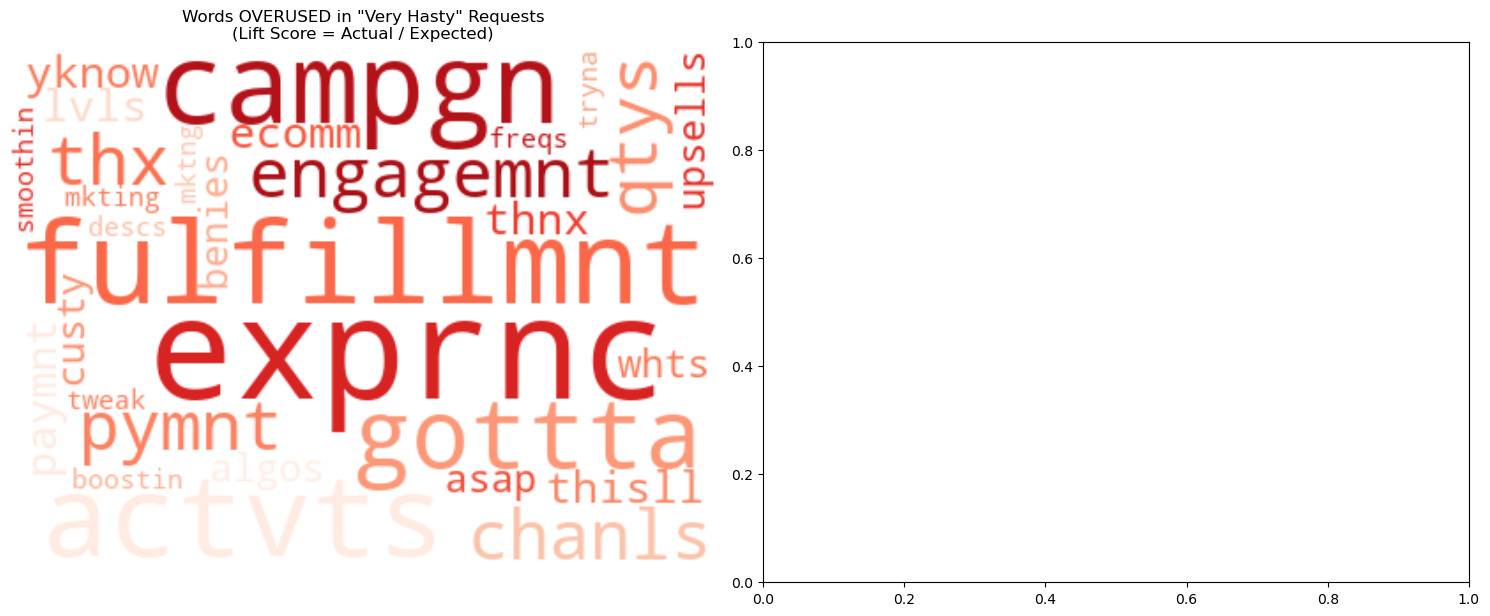

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

if hasty_lift:
    wc1 = WordCloud(
        width=400, height=300, 
        background_color='white', 
        colormap='Reds', 
        max_words=30
    )
    wc1.generate_from_frequencies(hasty_lift)
    axes[0].imshow(wc1, interpolation='bilinear')
    axes[0].axis('off')
    axes[0].set_title('Words OVERUSED in "Very Hasty" Requests\n(Lift Score = Actual / Expected)', fontsize=12)

if formal_lift:
    wc2 = WordCloud(
        width=400, height=300, 
        background_color='white', 
        colormap='Blues', 
        max_words=30
    )
    wc2.generate_from_frequencies(formal_lift)
    axes[1].imshow(wc2, interpolation='bilinear')
    axes[1].axis('off')
    axes[1].set_title('Words OVERUSED in "Very Formal" Requests\n(Lift Score = Actual / Expected)', fontsize=12)

plt.tight_layout()
plt.show()

In [45]:
#converting it to z scores
def get_zscore_words(df, group_value, baseline, top_n=30):
    group_df = df[df['Hastiness'] == group_value]
    group_words = [w for words in group_df['Clean_Words'] for w in words]
    group_counter = Counter(group_words)
    total_group_words = len(group_words)
    
    scores = {}
    for word in group_counter.keys():
        obs_count = group_counter.get(word, 0)
        obs_freq = obs_count / total_group_words if total_group_words > 0 else 0
        exp_freq = baseline.get(word, 1e-12)
        
        freq_across_groups = []
        for group in df['Hastiness'].unique():
            g_df = df[df['Hastiness'] == group]
            g_words = [w for words in g_df['Clean_Words'] for w in words]
            if len(g_words) > 0:
                g_count = Counter(g_words).get(word, 0)
                freq_across_groups.append(g_count / len(g_words))
        
        if len(freq_across_groups) > 1:
            std_dev = np.std(freq_across_groups)
        else:
            std_dev = 1e-12
        
        if std_dev > 0:
            z_score = (obs_freq - exp_freq) / std_dev
            if z_score > 0:
                scores[word] = z_score
    
    sorted_words = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
    return dict(sorted_words)

In [46]:
# Calculate Z-scores for Hasty and Formal
print("\nCalculating Z-Scores...")
hasty_z = get_zscore_words(df, 'Very Hasty', ngram_baseline)
formal_z = get_zscore_words(df, 'Very Formal', ngram_baseline)


Calculating Z-Scores...


In [47]:
print("\nTop 10 words overused in 'Very Hasty' (Z-score):")
for word, score in list(hasty_z.items())[:10]:
    print(f"  {word}: Z = {score:.2f}")

print("\nTop 10 words overused in 'Very Formal' (Z-score):")
for word, score in list(formal_z.items())[:10]:
    print(f"  {word}: Z = {score:.2f}")


Top 10 words overused in 'Very Hasty' (Z-score):
  chain: Z = 155.27
  supply: Z = 101.69
  coverage: Z = 46.92
  shop: Z = 46.52
  underwriting: Z = 31.74
  lifecycle: Z = 26.71
  risk: Z = 23.94
  channels: Z = 21.81
  records: Z = 21.79
  logistics: Z = 19.75

Top 10 words overused in 'Very Formal' (Z-score):


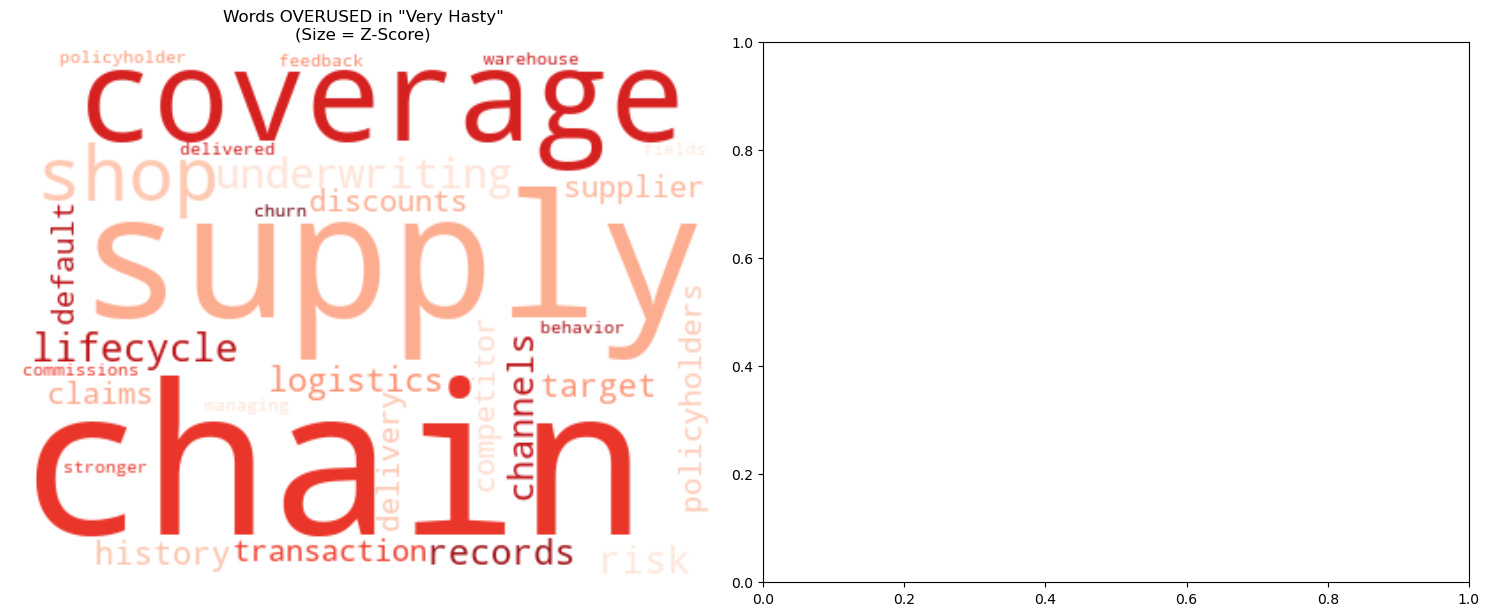

In [48]:
# Generate Word Clouds
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Hasty Word Cloud
if hasty_z:
    wc1 = WordCloud(
        width=400, height=300, 
        background_color='white', 
        colormap='Reds', 
        max_words=30
    )
    wc1.generate_from_frequencies(hasty_z)
    axes[0].imshow(wc1, interpolation='bilinear')
    axes[0].axis('off')
    axes[0].set_title('Words OVERUSED in "Very Hasty"\n(Size = Z-Score)', fontsize=12)

# Formal Word Cloud
if formal_z:
    wc2 = WordCloud(
        width=400, height=300, 
        background_color='white', 
        colormap='Blues', 
        max_words=30
    )
    wc2.generate_from_frequencies(formal_z)
    axes[1].imshow(wc2, interpolation='bilinear')
    axes[1].axis('off')
    axes[1].set_title('Words OVERUSED in "Very Formal"\n(Size = Z-Score)', fontsize=12)

plt.tight_layout()
plt.show()

In [49]:
def get_hasty_vs_formal_words(df, top_n=30):
    """
    Find words that are overused in Hasty vs Formal requests.
    This compares the two groups directly, not against NGRAMS.
    """
    # Get words for each group
    hasty_df = df[df['Hastiness'] == 'Very Hasty']
    formal_df = df[df['Hastiness'] == 'Very Formal']
    
    hasty_words = [w for words in hasty_df['Clean_Words'] for w in words]
    formal_words = [w for words in formal_df['Clean_Words'] for w in words]
    
    hasty_counter = Counter(hasty_words)
    formal_counter = Counter(formal_words)
    
    total_hasty = len(hasty_words)
    total_formal = len(formal_words)
    
    scores = {}
    
    # Get all unique words from both groups
    all_words = set(hasty_counter.keys()) | set(formal_counter.keys())
    
    for word in all_words:
        hasty_count = hasty_counter.get(word, 0)
        formal_count = formal_counter.get(word, 0)
        
        hasty_freq = hasty_count / total_hasty if total_hasty > 0 else 0
        formal_freq = formal_count / total_formal if total_formal > 0 else 0
        
        # Calculate log-fold change (how much more common in Hasty vs Formal)
        if formal_freq > 0 and hasty_freq > 0:
            log_fold = np.log2(hasty_freq / formal_freq)
            if log_fold > 0:  # Only keep words overused in Hasty
                scores[word] = log_fold
    
    # Sort by highest log-fold change
    sorted_words = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
    return dict(sorted_words)

# --- Calculate Hasty vs Formal words ---
print("\nCalculating Hasty vs Formal overused words...")
hasty_overused = get_hasty_vs_formal_words(df)

print("\nTop 10 words OVERUSED in 'Very Hasty' compared to 'Very Formal':")
for word, score in list(hasty_overused.items())[:10]:
    print(f"  {word}: {score:.2f}x more common in Hasty")


Calculating Hasty vs Formal overused words...

Top 10 words OVERUSED in 'Very Hasty' compared to 'Very Formal':
